## Libraries and data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pint.models as models
import pint.toa as toa
import pint.residuals as residuals
import astropy.units as u
from pathlib import Path
import os

In [2]:
path = Path(r"C:\Users\seren\Desktop\pulsar")

In [3]:
#!this works for PINT files!
par_path = path/"J1909-3744_PINT_20220303.nb.par"
tim_path = path/"J1909-3744_PINT_20220303.nb.tim"
if not par_path.exists():
    print("file not found")
else:
    print("found")

found


In [4]:
m = models.get_model(str(par_path))
t = toa.get_TOAs(str(tim_path),model=m)
print(f"pulsar {m.PSR.value} downloaded")

2026-05-16 16:11:37.346 | DEBUG    | pint.toa:get_TOAs:195 - Using EPHEM = DE440 from the given model
2026-05-16 16:11:37.349 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2019 from the given model
2026-05-16 16:11:37.349 | DEBUG    | pint.toa:get_TOAs:232 - Using PLANET_SHAPIRO = True from the given model
2026-05-16 16:12:09.123 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = True)
2026-05-16 16:12:14.043 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2026-05-16 16:12:14.049 | DEBUG    | pint.observatory:_load_gps_clock:108 - Loading global GPS clock file
2026-05-16 16:12:14.095 | DEBUG    | pint.observatory.clock_file:__init__:812 - Global clock file gps2utc.clk saving kwargs={'bogus_last_correction': False, 'valid_beyond_ends': False}
2026-05-16 16:12:14.137 | DEBUG    | pint.observatory.clock_file:read_tempo2_clock_file:463 - Loading TEMPO2-format observatory clock c

pulsar J1909-3744 downloaded


In [5]:
res = residuals.Residuals(t,m)

2026-05-16 16:13:22.756 | INFO     | pint.solar_system_ephemerides:load_kernel:194 - Set solar system ephemeris to de440 through astropy
2026-05-16 16:13:27.689 | INFO     | pint.solar_system_ephemerides:load_kernel:194 - Set solar system ephemeris to de440 through astropy
2026-05-16 16:13:28.216 | DEBUG    | pint.toa:add_vel_ecl:2496 - Adding column ssb_obs_vel_ecl
2026-05-16 16:13:28.216 | DEBUG    | pint.models.astrometry:ssb_to_psb_xyz_ECL:983 - ECL not specified; using IERS2010.
2026-05-16 16:13:28.256 | DEBUG    | pint.models.astrometry:ssb_to_psb_xyz_ECL:983 - ECL not specified; using IERS2010.
2026-05-16 16:13:28.317 | DEBUG    | pint.models.astrometry:ssb_to_psb_xyz_ECL:983 - ECL not specified; using IERS2010.
2026-05-16 16:13:28.587 | DEBUG    | pint.models.astrometry:ssb_to_psb_xyz_ECL:983 - ECL not specified; using IERS2010.
2026-05-16 16:13:28.806 | DEBUG    | pint.models.absolute_phase:get_TZR_toa:101 - Creating and dealing with the single TZR_toa for absolute phase
2026-

## Plot residuals

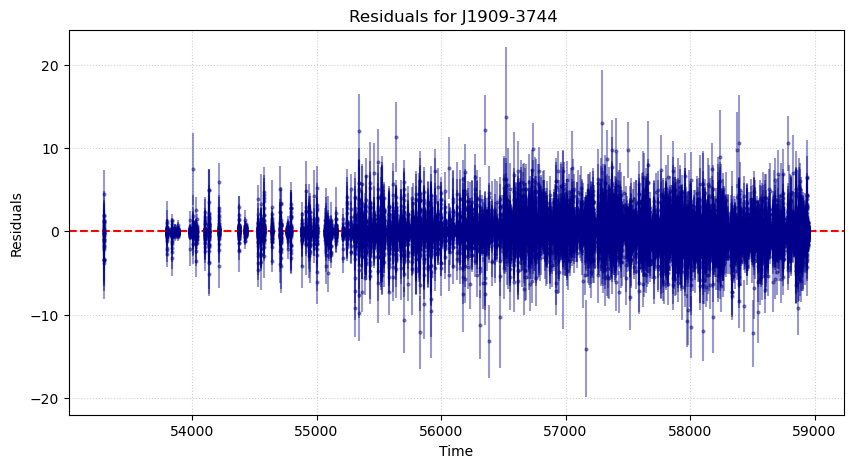

In [6]:
plt.figure(figsize = (10,5))

y_values= res.time_resids.to(u.us).value
x_values= t.get_mjds().value
y_err= t.get_errors().to(u.us).value

plt.errorbar(x_values, y_values, yerr=y_err,fmt ='o',markersize=2, alpha=0.4, color='darkblue')

plt.axhline(0,color='red',linestyle = '--',label="theory GR")
plt.title(f"Residuals for {m.PSR.value} ")
plt.xlabel("Time")
plt.ylabel("Residuals")
plt.grid(True, linestyle = ':', alpha = 0.6)
plt.show()

## Orbital elements and post keplerian parameter 

In [7]:
#orbital elements
pb   = m.PB.value #orbital period (days)
a1   = m.A1.value #semimajor axis
e1   = m.EPS1.value #e*sin(omega)
e2   = m.EPS2.value #e*cos(omega)
e   = np.sqrt(e1**2 + e2**2) #eccentricity
omega = np.arctan2(e1,e2) #argument of periastron
t0   = m.TASC.value #time
m2   = m.M2.value #comp mass
r    = 4.925490947e-6 *m2
sini = m.SINI.value #sin of inclinantion

# Post-Keplerian parameters
print("Post keplerian parameters:")
#there isn't gamma. NanoGRAV is full of millisecond pulsars with e smaller than 1e-6, so they can't measure gamma.
if hasattr(m, 'GAMMA'):
    gamma = m.GAMMA.value
    print(f"γ : {gamma*1e6:.3f} μs")
else:
    print("γ : Not available")

if hasattr(m, 'PBDOT') and m.PBDOT.value is not None:
    pbdot = m.PBDOT.value
    print(f"Ṗ_b : {pbdot:.2e} days")
else:
    print("Ṗ_b: Not available")

if hasattr(m, 'OMDOT') and m.OMDOT.value is not None:
    omdot = m.OMDOT.value
    print(f"ω̇ : {omdot:.3f} deg/yr")
else:
    print("ω̇ :Not available")

if hasattr(m, 'M2'):
    m2_val = m.M2.value
    print(f"M2: {m2_val:.4f} M⊙")
else:
    print("M2: Not available")

print("e: {:.2e}".format(e))

#shapiro parameters
shapiro_params = []
if hasattr(m, 'SINI') and getattr(m.SINI, 'value', None) is not None:
    shapiro_params.append(f"sin(i): {m.SINI.value:.4f}")

if hasattr(m, 'SHAPMAX') and getattr(m.SHAPMAX, 'value', None) is not None:
    shapiro_params.append(f"SHAPMAX: {m.SHAPMAX.value:.2e}")

if hasattr(m, 'RNGMAX') and getattr(m.RNGMAX, 'value', None) is not None:
    shapiro_params.append(f"RNGMAX: {m.RNGMAX.value:.2e}")
else: 
    print("Range: Not available")

if shapiro_params:
    for param in shapiro_params:
        print(f"{param}")

Post keplerian parameters:
γ : Not available
Ṗ_b : 5.09e-13 days
ω̇ :Not available
M2: 0.2087 M⊙
e: 1.09e-07
Range: Not available
sin(i): 0.9980


In [8]:
#orbital phase
mjds = t.get_mjds().value
phase = ((mjds - t0) / pb) % 1  
sort_idx = np.argsort(phase)
phase_sorted = phase[sort_idx]
phase_centered = phase_sorted - 0.5  # center around 0 (I want to see the peak :) )

In [9]:
#eccentric anomaly
u = 2*np.pi * phase  
u_sort = u[sort_idx]
u_shifted = u_sort - 2*np.pi * np.round(u_sort/(2*np.pi))  

## delays (Roemer-Shapiro)

In [10]:
#extraction of reomer, shapiro 
#gamma is approximately 0 so it isn't included

fe = (np.cos(u_shifted)*np.sin(omega) - e1 + np.sqrt(1 - e**2)*np.cos(u_shifted)*np.cos(omega))
roemer = a1 * sini *(np.cos(u_shifted)*np.sin(omega) - e1 + np.sqrt(1 - e**2)*np.cos(u_shifted)*np.cos(omega))  # include omega for more accuracy
roemer_centered = a1 * sini *(np.cos(u_shifted - np.pi/2)*np.sin(omega) - e1 + np.sqrt(1 - e**2)*np.cos(u_shifted - np.pi/2)*np.cos(omega))  # shift to center the peak at phase=0.5
shapiro = -2*r*np.log(1-sini*np.cos(u_sort))
shapiro_centered = -2*r*np.log(1-sini*np.cos(u_sort -np.pi))  # shift to center the peak at phase=0.5


In [11]:
#value of delays
print(f"Roemer delay: {np.max(roemer):.3f} s")
     
print(f"Shapiro delay: {np.max(shapiro)*1e6:.3f} μs")

Roemer delay: 0.950 s
Shapiro delay: 12.783 μs


### **plot**

Text(0, 0.5, 'Delay (μs)')

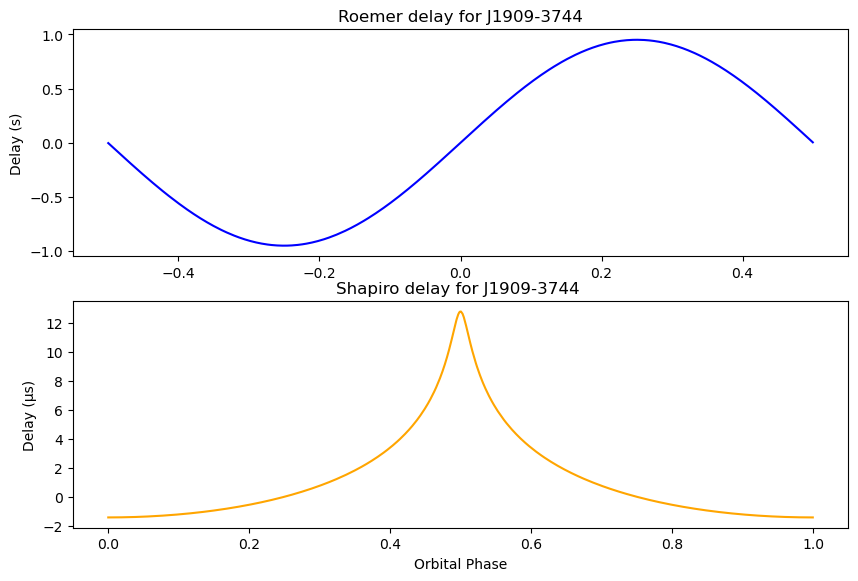

In [12]:
plt.figure(figsize=(10,10))
plt.subplot(3,1,1)
plt.plot(phase_centered, roemer_centered, label='Roemer delay', color='blue')
plt.title(f"Roemer delay for {m.PSR.value}")
plt.ylabel("Delay (s)")
plt.subplot(3,1,2)
plt.plot(phase_sorted, shapiro_centered*1e6, label='Shapiro delay', color='orange')
plt.title(f"Shapiro delay for {m.PSR.value} ")
plt.xlabel("Orbital Phase")
plt.ylabel("Delay (μs)")

## failed part

In [13]:
m1 = np.linspace(0.1, 2.5, 100)  # mass of the pulsar

p_dot_value = getattr(m, 'PBDOT', None)
p_dot= abs(getattr(p_dot_value, 'value', None))
pb_sec = pb * 86400  # convert orbital period from days to seconds
T_sun = 4.925490947e-6  # solar mass in seconds

m2_from_sini = ((a1**3/(T_sun*(pb_sec/(2*np.pi))**2))*(m1 + m2)**2)**(1/3)/sini
#there is something wrong with this
m2_from_pdoT = ((5*p_dot /(192*np.pi))*(pb_sec/(2*np.pi*T_sun))**(5/3)*(m1+m2)**(1/3))/m1
m2_from_range = r / T_sun


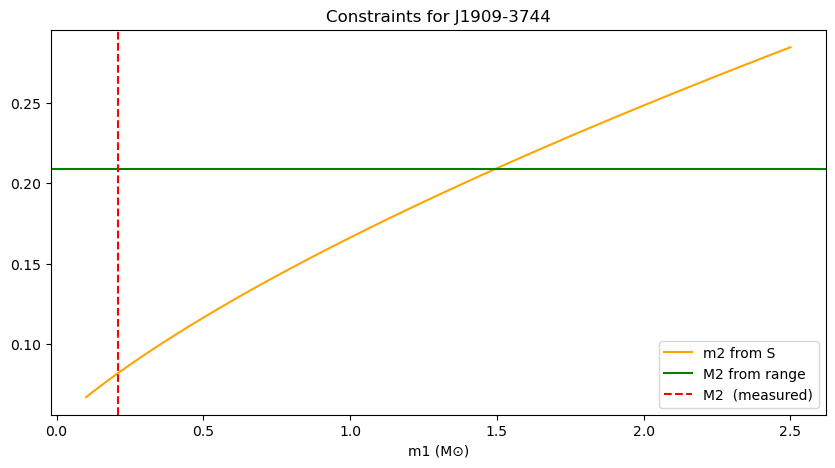

In [14]:

plt.figure(figsize=(10,5))
plt.plot(m1, m2_from_sini, label='m2 from S', color='orange')
#plt.plot(m1, m2_from_pdoT, label='m2 from Pb', color='purple')

#line form range
plt.axhline(m2_from_range, color='green', label='M2 from range')

plt.axvline(m2, color='red', linestyle='--', label='M2  (measured)')
plt.title(f"Constraints for {m.PSR.value}")
plt.xlabel("m1 (M⊙)")
plt.legend()

In [15]:
#intersection of constraints
#at least the value of m1 is around 1.4 M⊙, which is a typical neutron star mass
m1_val = np.where(np.isclose(m2_from_sini, m2_from_range, atol=0.001))[0]
m1_found = m1[m1_val]
print("intersection of constraints at m1 =", m1_found, "M⊙")


intersection of constraints at m1 = [1.48181818] M⊙
